# General Task Performance 

In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging

from monoculture.analysis.setup import ACS_TASKS, TABLESHIFT_TASKS, baselines
from monoculture.analysis.metrics import (
    pairwise_agreement_at_random,
    matrix_pairwise_evals,
    pairwise_agreement_at_random,
)

from monoculture.analysis.utils import (
    key_to_model,
    prettify_model_name,
    get_size,
    get_size_and_it,
    is_instruction_tuned,
    load_model_outputs_same_prompt,
    get_metric,
    load_task_data,
)
from monoculture.baseline.utils import load_baselines

from monoculture.analysis.plotting import (
    plot_accuracies,
    plot_label_dist,
    plot_neg_predicted,
)

In [3]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

TASKS = ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR / "overview_results_by_prompt_style.csv"
FIGURES_ROOT_DIR = RESULTS_ROOT_DIR / "figures/"

data = None

tasks ('ACSIncome', 'ACSEmployment', 'ACSTravelTime', 'ACSPublicCoverage', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure')


## Load Task Data

In [4]:
data_dir = Path("./data")
data = load_task_data(TASKS, data_dir)

## Load Baselines

In [5]:
baseline_scores, baseline_evals = load_baselines(baselines=baselines, tasks=TASKS)

logging.warning("Manually changed values.")
baseline_evals["BRFSS_Diabetes"]["XGBoost"] = {"accuracy": 0.0}
baseline_evals["BRFSS_Blood_Pressure"]["XGBoost"] = {"accuracy": 0.0}


baseline_predictions = {
    task: baseline_scores[task].map(lambda x: int(x >= 0.5)) for task in TASKS
}
baseline_predictions["ACSIncome"].head()

Loading baselines for ACSIncome.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSIncome'.
- LR: Load predictions from 'results/baselines/LR_task-ACSIncome'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSIncome'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSIncome'.
Loading baselines for ACSEmployment.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSEmployment'.
- LR: Load predictions from 'results/baselines/LR_task-ACSEmployment'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSEmployment'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSEmployment'.
Loading baselines for ACSTravelTime.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSTravelTime'.
- LR: Load predictions from 'results/baselines/LR_task-ACSTravelTime'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSTravelTime'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-A

- GBM: Load predictions from 'results/baselines/GBM_task-ACSPublicCoverage'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSPublicCoverage'.
Loading baselines for BRFSS_Diabetes.
- Constant: Load predictions from 'results/baselines/Constant_task-BRFSS_Diabetes'.
Skipping LR
Skipping GBM
Skipping XGBoost
Loading baselines for BRFSS_Blood_Pressure.
- Constant: Load predictions from 'results/baselines/Constant_task-BRFSS_Blood_Pressure'.
Skipping LR
Skipping GBM
Skipping XGBoost


,Constant_task-ACSIncome,LR_task-ACSIncome,GBM_task-ACSIncome,XGBoost_task-ACSIncome
238351,0,0,0,0
2995677,0,0,0,0
2360043,0,0,1,1
1924596,0,0,0,0
2803585,0,0,0,0


## Load predictions

In [6]:
num_shots = 0
threshold_fitted = 1

df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df_same_prompt = df[
    (df["num_shots"] == num_shots)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == threshold_fitted)
]
df_same_prompt.head()

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
1,ACSIncome,meta-llama--Meta-Llama-3.2-1B-Instruct,1,1,0.776744,0.680409,3019759728,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
2,ACSIncome,allenai--OLMo-2-1124-7B-Instruct,1,1,0.904552,0.727768,3118177042,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-allenai--O...,results/folktexts/0-bullet-is/model-allenai--O...
4,ACSIncome,google--gemma-2-27b,0,1,0.438475,0.510381,3621160589,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
6,ACSIncome,google--gemma-2-27b-it,1,1,0.867235,0.659718,1712994131,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
9,ACSIncome,meta-llama--Meta-Llama-3-70B,0,1,0.532134,0.763641,4121241683,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...


In [7]:
print(df_same_prompt.shape)
try:
    assert set(TASKS).issubset(
        set(df_same_prompt["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df_same_prompt['task'].unique())} "
except AssertionError:
    logging.warning("Reduced TASKS to available tasks.")
    TASKS = list(df_same_prompt["task"].unique())
TASKS

(288, 14)


('ACSIncome',
 'ACSEmployment',
 'ACSTravelTime',
 'ACSPublicCoverage',
 'BRFSS_Diabetes',
 'BRFSS_Blood_Pressure')

In [8]:
risk_scores = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=True
)
predictions_all = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=False
)

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for metric in metrics:
    df_same_prompt[metric] = (
        df_same_prompt["eval_results_path"]
        .apply(partial(get_metric, metric=metric))
        .copy()
    )

evals_per_task = {}  # [task][metric][model]
for task in df_same_prompt["task"].unique():
    df_task = df_same_prompt[df_same_prompt["task"] == task]
    evals_per_task[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }

/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_49478/3355898873.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_49478/3355898873.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_49478/3355898873.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

## Restrict analysis to models based on performance?

*Currently not used*

In [9]:
restrict_to_better_const = True
restrict_to_positive_label = False
restrict_to_negative_label = False
assert not (
    restrict_to_positive_label & restrict_to_negative_label
), "Choose one or none."

predictions = predictions_all.copy()
models_better_const = {
    task: [
        m
        for m in predictions[task].columns
        if df_same_prompt[
            (df_same_prompt["task"] == task) & (df_same_prompt["model"] == m)
        ]["accuracy"].item()
        > baseline_evals[task]["Constant"]["accuracy"]
    ]
    for task in TASKS
}


if any(
    [restrict_to_better_const, restrict_to_positive_label, restrict_to_negative_label]
):
    if not data:
        logging.warning("Load task data")
        data = load_task_data(TASKS, Path("./data"))

    for task in TASKS:
        df_task = df_same_prompt[df_same_prompt["task"] == task]
        y_true = data[task][1]

        if restrict_to_better_const:
            const_acc = max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
            models_better_const[task] = sorted(
                df_task["model"][df_task["accuracy"] > const_acc].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(
                items=models_better_const[task]
            )

        if restrict_to_negative_label or restrict_to_positive_label:
            filter_idx = y_true[y_true == int(restrict_to_positive_label)].index
            predictions[task] = predictions[task].loc[filter_idx]
        print(task, predictions[task].shape)

ACSIncome (166450, 40)
ACSEmployment (323611, 42)
ACSTravelTime (146665, 19)
ACSPublicCoverage (113829, 12)
BRFSS_Diabetes (144418, 0)
BRFSS_Blood_Pressure (84676, 36)


## Plot Accuracy

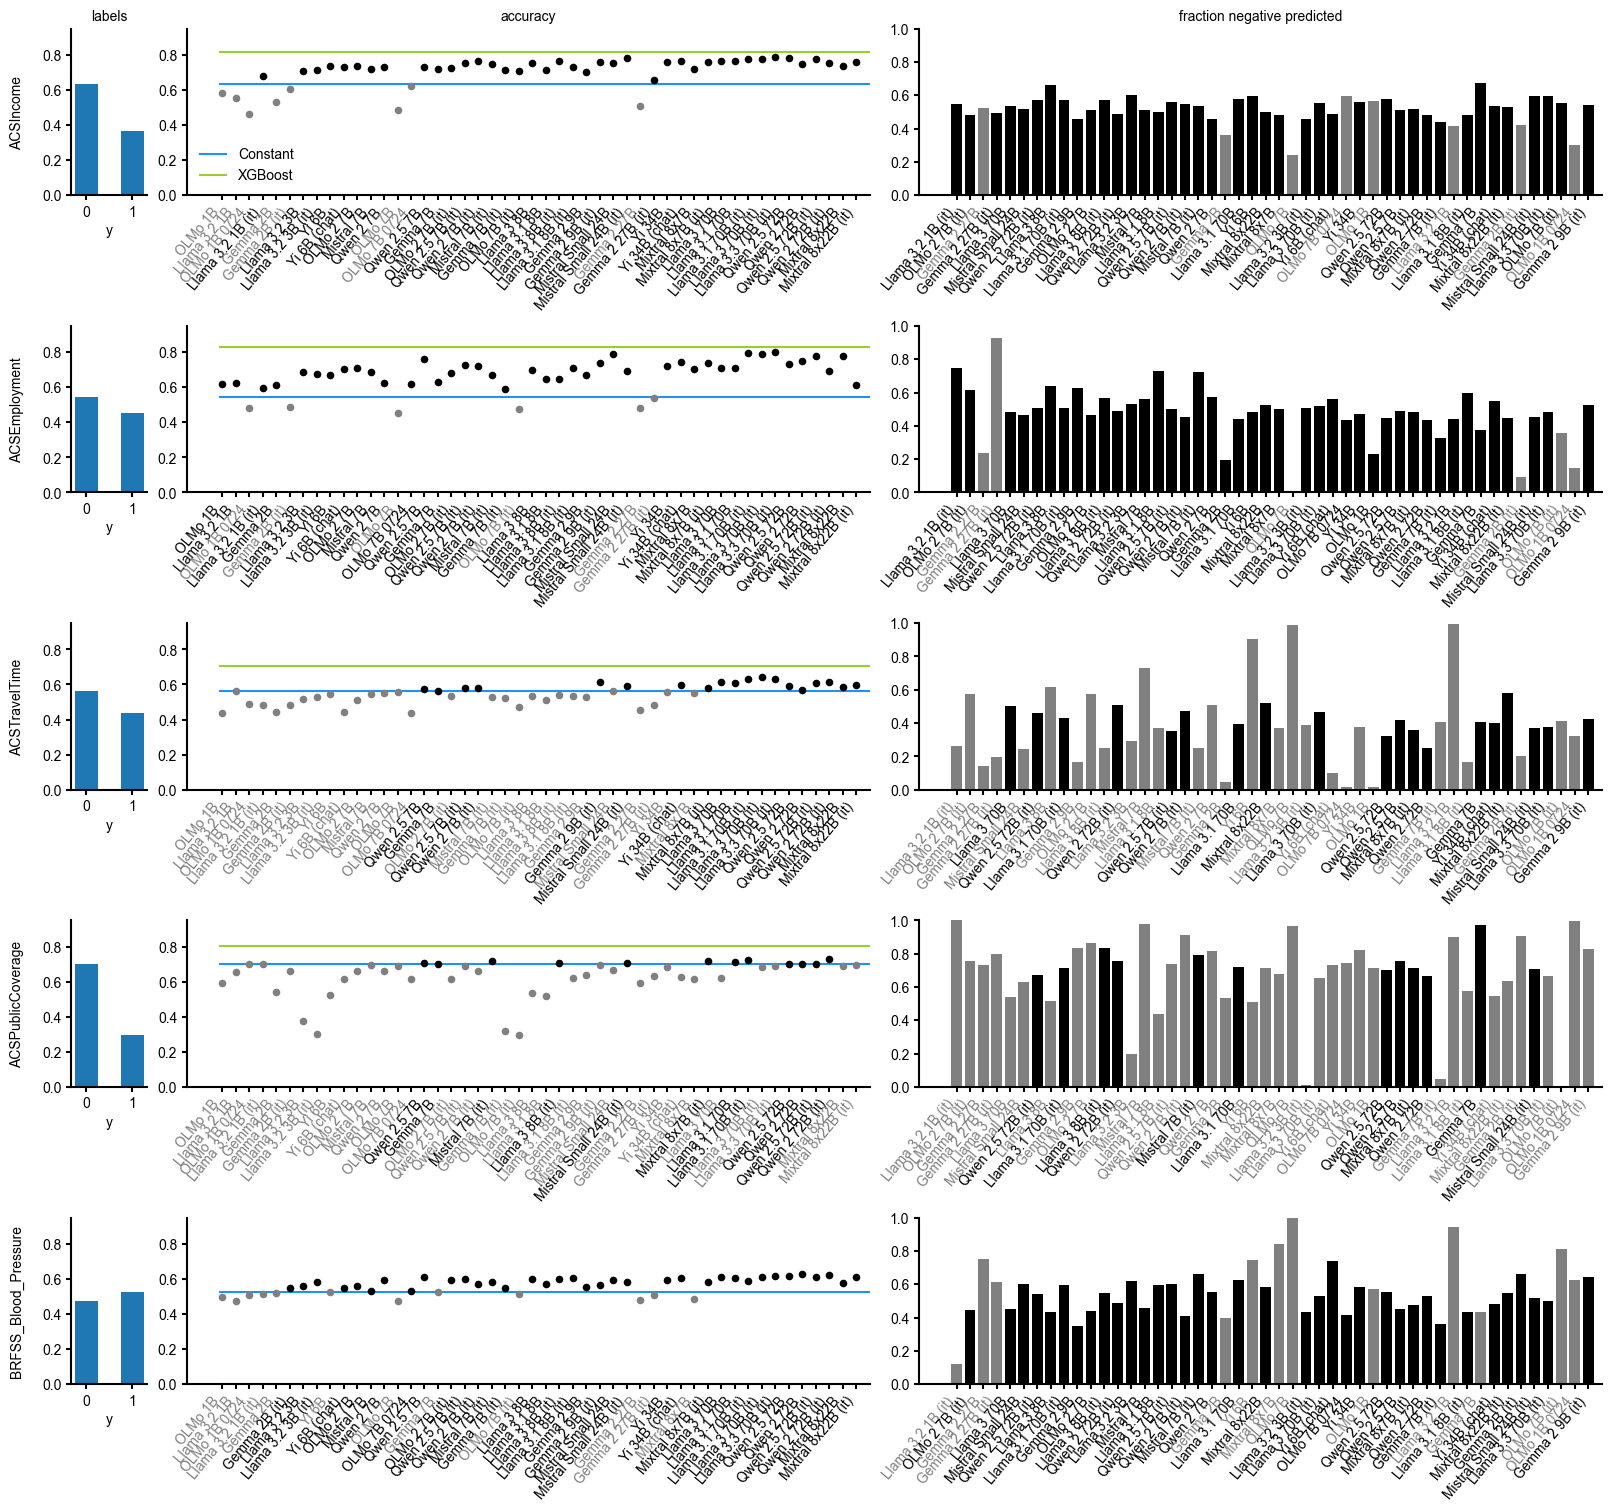

In [10]:
# one big plot
tasks_to_plot = [
    task for task in TASKS if task != "ACSMobility" and predictions[task].shape[1] > 0
]

fig, axs = plt.subplots(
    len(tasks_to_plot),
    3,
    figsize=(16, 3 * len(tasks_to_plot)),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [1, 9, 9]},
)
axs[0, 0].set_title("labels")
axs[0, 1].set_title("accuracy")
axs[0, 2].set_title("fraction negative predicted")
pad = 5  # pt

for i, task in enumerate(tasks_to_plot):
    axs[i, 0].annotate(
        task,
        xy=(0, 0.5),
        xytext=(-axs[i, 0].yaxis.labelpad - pad, 0),
        xycoords=axs[i, 0].yaxis.label,
        textcoords="offset points",
        size="medium",
        ha="right",
        va="center",
        rotation=90,
    )

    # label distribution
    y_true = data[task][1]
    axs[i, 0] = plot_label_dist(axs[i, 0], y_true, ylims=(0, 0.95))

    # model accuracy
    axs[i, 1] = plot_accuracies(
        ax=axs[i, 1],
        task=task,
        evals=evals_per_task,
        baseline_evals=baseline_evals,
        models_above_baseline=models_better_const,
        ylims=(0, 0.95),
        hline_xmin=-0.2,
        hline_xmax=predictions_all[task].shape[1] + 0.1,
    )

    # fraction of negative predicted samples
    axs[i, 2] = plot_neg_predicted(
        axs[i, 2],
        task=task,
        evals=evals_per_task,
        models_above_baseline=models_better_const,
    )

    axs[0, 1].legend()

file_name = "".join(
    [
        f"{num_shots}-shot-model-performance",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_better_const" if restrict_to_better_const else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
        ".png",
    ]
)
plt.savefig(FIGURES_ROOT_DIR / "paper" / file_name)
plt.show()

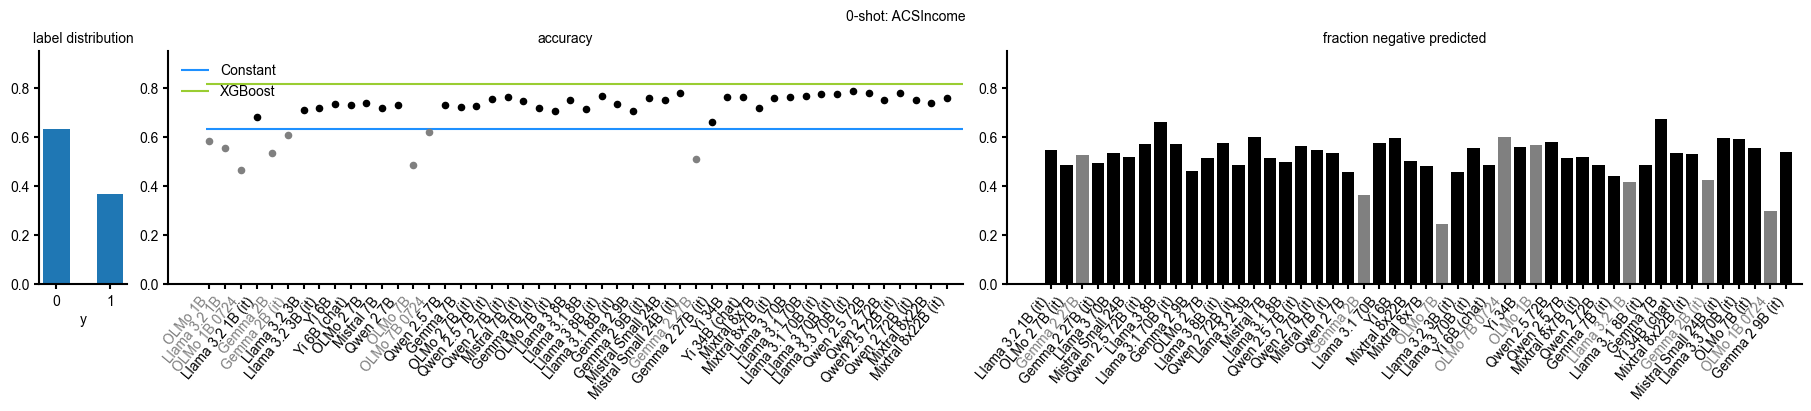

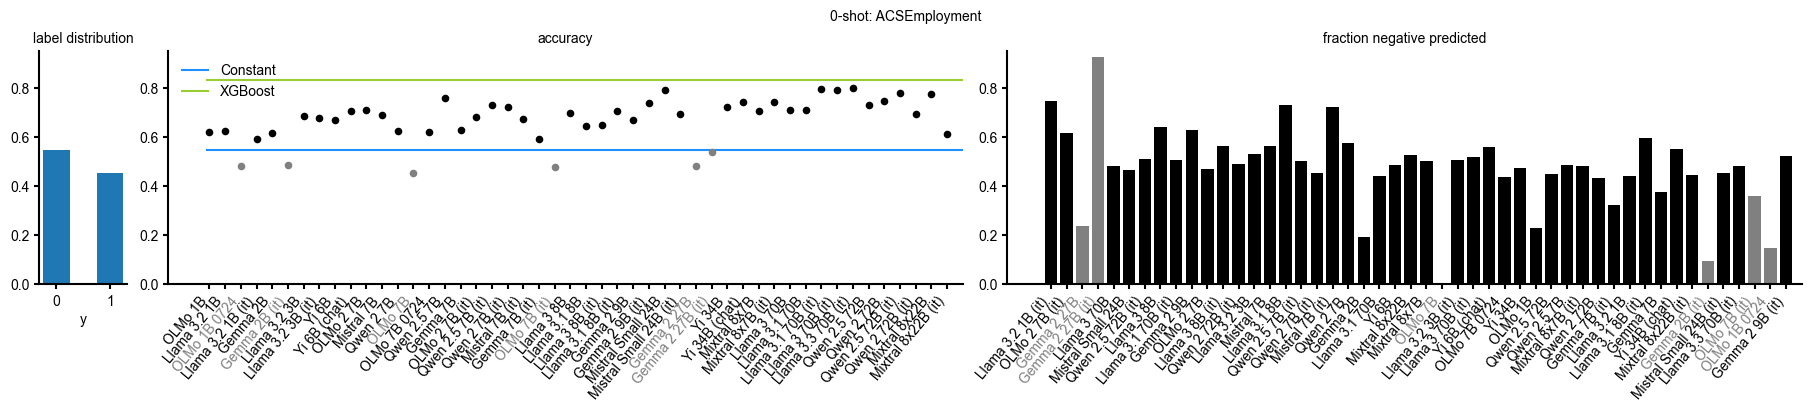

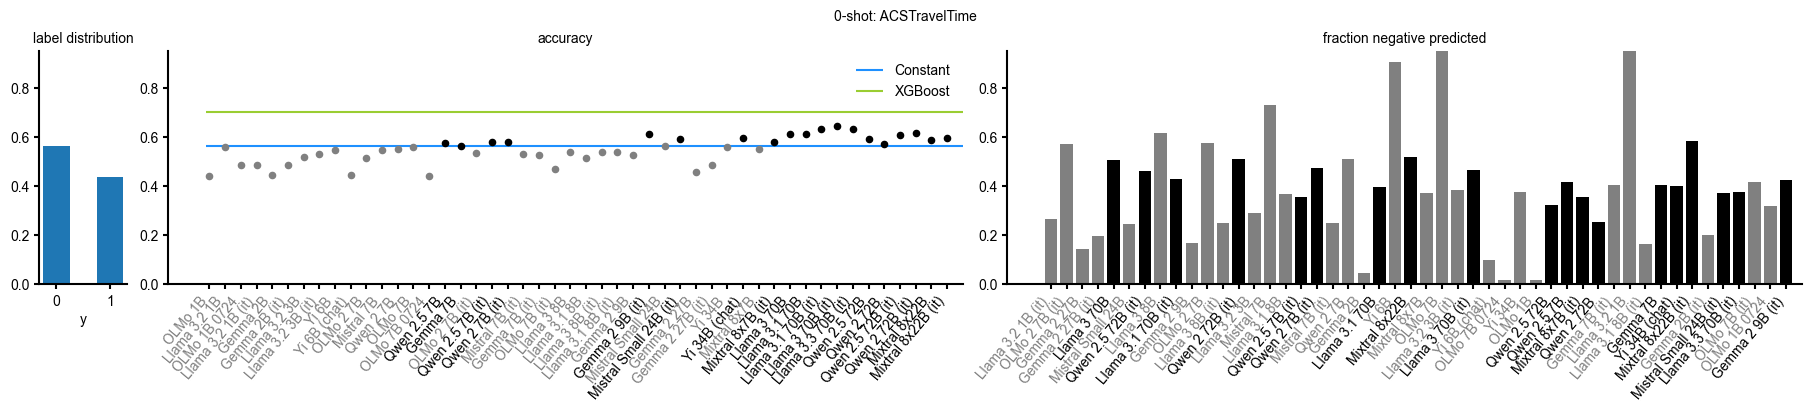

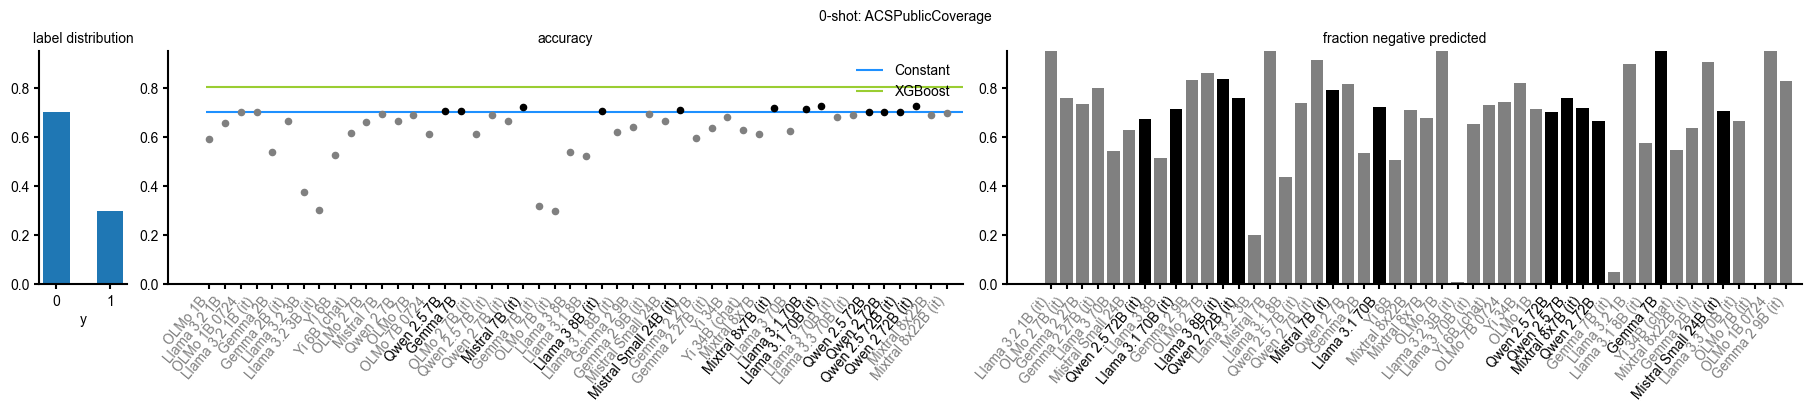

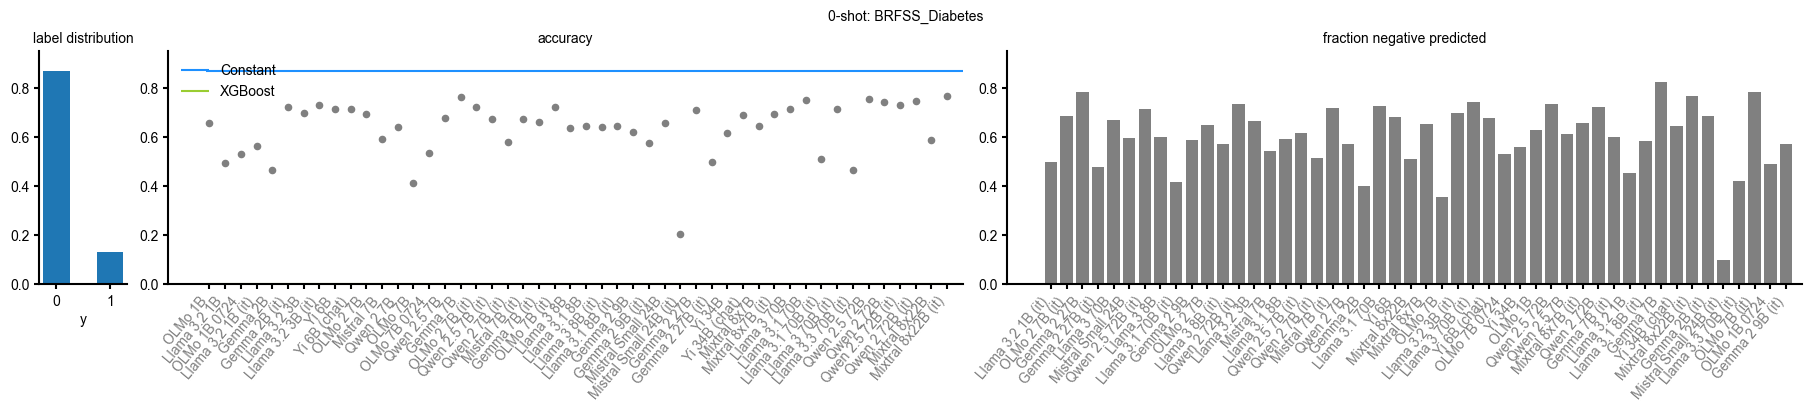

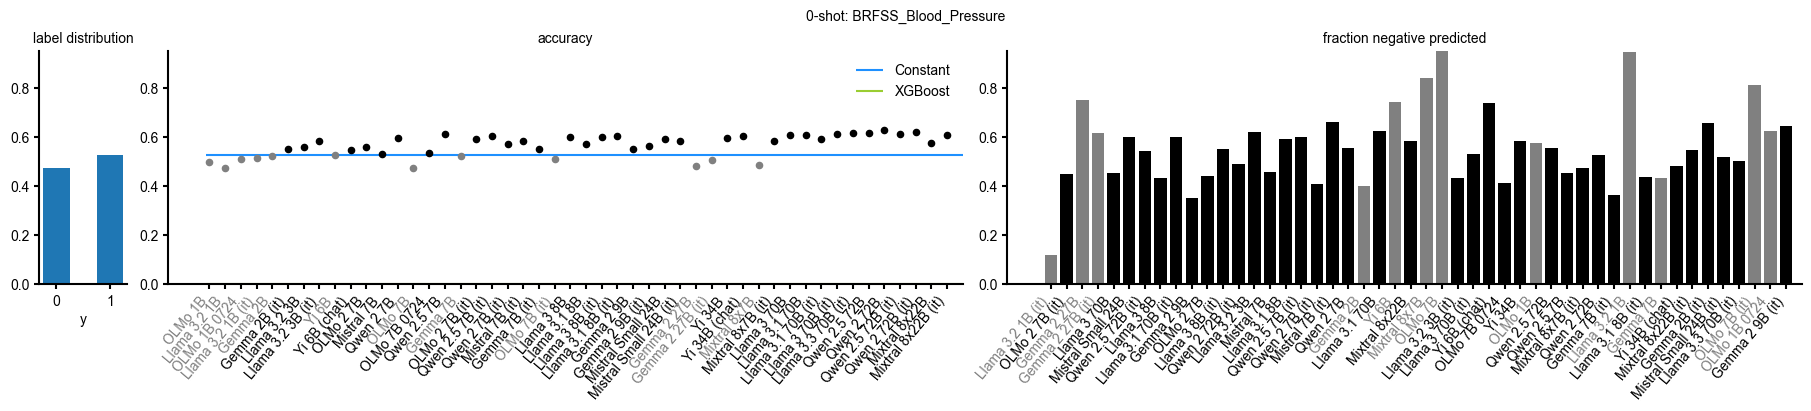

In [11]:
# one plot per task
for task in TASKS:  # , 'ACSEmployment', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure']:
    fig, axs = plt.subplots(
        1,
        3,
        figsize=(18, 4),
        constrained_layout=True,
        gridspec_kw={"width_ratios": [1, 9, 9]},
    )
    fig.suptitle(f"{num_shots}-shot: {task}")
    axs[0].set_title("label distribution")
    axs[1].set_title("accuracy")
    axs[2].set_title("fraction negative predicted")
    pad = 5  # pt
    # axs[0].annotate(task, xy=(0, 0.5), xytext=(-axs[0].yaxis.labelpad - pad, 0), xycoords=axs[0].yaxis.label, textcoords='offset points', size='medium', ha='right', va='center')

    ylims = (0, 0.95)
    # label distribution
    labels = data[task][1]
    axs[0] = plot_label_dist(axs[0], labels, ylims=ylims)

    # model accuracy
    # to exclude constant classifiers: evals = evals_non_const
    axs[1] = plot_accuracies(
        ax=axs[1],
        task=task,
        evals=evals_per_task,
        baseline_evals=baseline_evals,
        models_above_baseline=models_better_const,
        hline_xmin=-0.2,
        hline_xmax=predictions_all[task].shape[1] + 0.1,
        ylims=ylims,
    )

    # fraction of negative predicted samples
    axs[2] = plot_neg_predicted(
        axs[2],
        task=task,
        evals=evals_per_task,
        models_above_baseline=models_better_const,
        omit_non_highlight_labels=False,
        ylims=ylims,
    )

    # if task == "ACSIncome":
    axs[1].legend()

    file_name = "".join(
        [
            f"{num_shots}-shot-model-performance",
            "_tresh_fitted" if threshold_fitted == 1 else "",
            "_better_const" if restrict_to_better_const else "",
            "_pos_instances" if restrict_to_positive_label else "",
            "_neg_instances" if restrict_to_negative_label else "",
            f"_{task.replace('ACS', 'ACS ').replace('_', ' ')}" ".png",
        ]
    )
    plt.savefig(FIGURES_ROOT_DIR / "paper" / file_name)
    plt.show()

## top-k models

In [12]:
top_k = 10
topk_models = {}
for task in TASKS:
    df_task = df_same_prompt[df_same_prompt["task"] == task].sort_values(
        by="accuracy", ascending=False
    )
    topk_models[task] = df_task.iloc[:top_k]
topk_models["ACSIncome"]

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path,n_samples,fpr,ppr,num_pred_negatives,num_pred_positives,balanced_accuracy
89,ACSIncome,meta-llama--Meta-Llama-3.3-70B-Instruct,1,1,0.999292,0.788483,364117336,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...,166450,0.198019,0.406705,98754,67696,0.783635
64,ACSIncome,Qwen--Qwen2.5-72B,0,1,0.320242,0.780667,3802773871,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-Qwen--Qwen...,results/folktexts/0-bullet-is/model-Qwen--Qwen...,166450,0.214747,0.420036,96535,69915,0.779020
87,ACSIncome,mistralai--Mistral-Small-24B-Instruct-2501,1,1,0.867116,0.780366,3235594015,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-mistralai-...,results/folktexts/0-bullet-is/model-mistralai-...,166450,0.202933,0.404800,99071,67379,0.774368
12,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.004614,0.777194,3970457559,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-Qwen--Qwen...,results/folktexts/0-bullet-is/model-Qwen--Qwen...,166450,0.223196,0.427245,95335,71115,0.777335
54,ACSIncome,meta-llama--Meta-Llama-3-70B-Instruct,1,1,0.974079,0.775903,2479635274,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...,166450,0.238108,0.444806,92412,74038,0.780935
16,ACSIncome,meta-llama--Meta-Llama-3.1-70B-Instruct,1,1,0.866530,0.774214,3398893713,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...,166450,0.227245,0.429384,94979,71471,0.774739
43,ACSIncome,meta-llama--Meta-Llama-3.1-70B,0,1,0.530337,0.767912,1155027540,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...,166450,0.227425,0.423310,95990,70460,0.766238
23,ACSIncome,meta-llama--Meta-Llama-3-8B-Instruct,1,1,0.952569,0.767275,3150350887,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...,166450,0.230020,0.425954,95550,70900,0.766304
35,ACSIncome,Qwen--Qwen2-7B-Instruct,1,1,0.119177,0.763773,403513459,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-Qwen--Qwen...,results/folktexts/0-bullet-is/model-Qwen--Qwen...,166450,0.254274,0.453115,91029,75421,0.770255
9,ACSIncome,meta-llama--Meta-Llama-3-70B,0,1,0.532134,0.763641,4121241683,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...,166450,0.263284,0.464374,89155,77295,0.773311


## Plot Risk Scores

In [13]:
models_common = set(risk_scores[TASKS[0]].columns)
for task in TASKS[1:]:
    models_common = models_common.intersection(set(risk_scores[task].columns))

ACSIncome


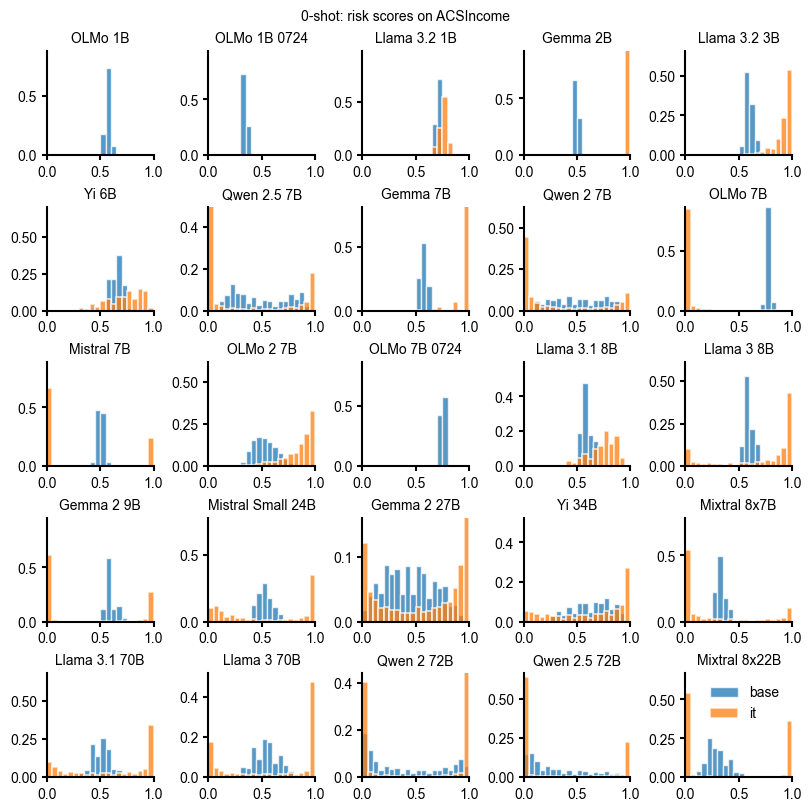

ACSEmployment


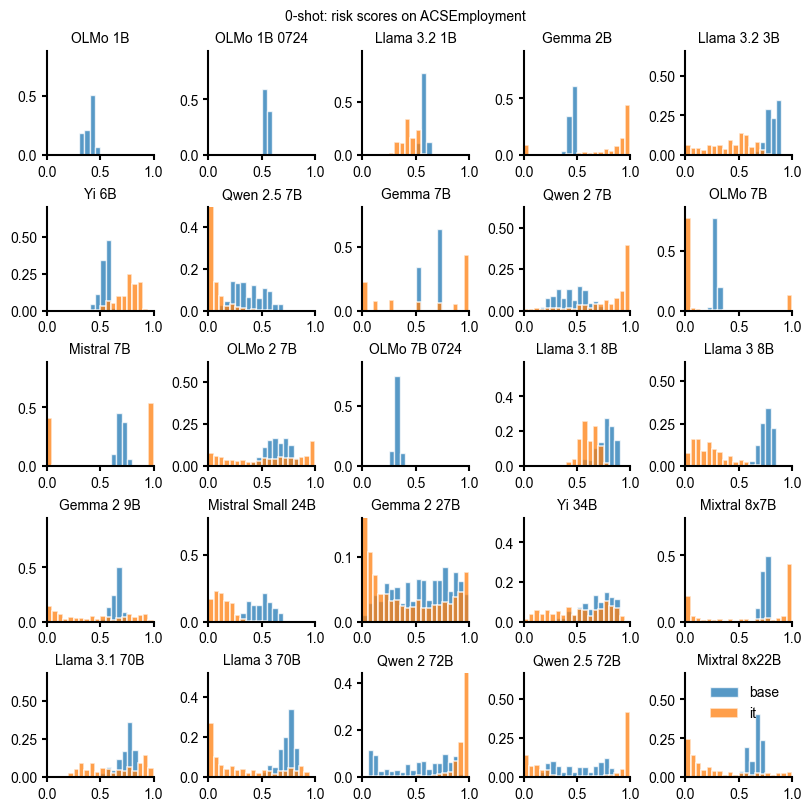

ACSTravelTime


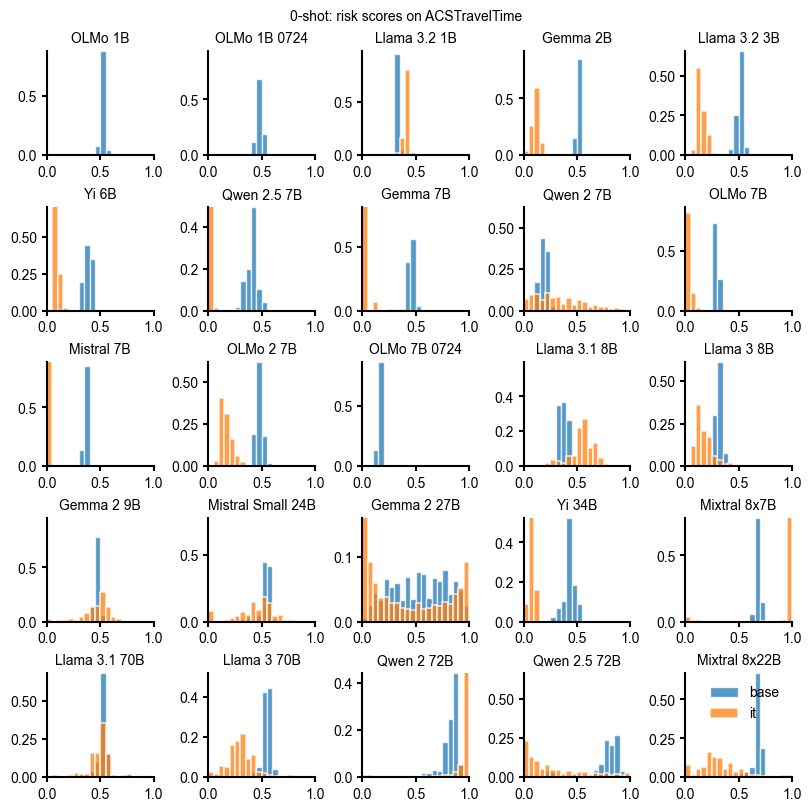

ACSPublicCoverage


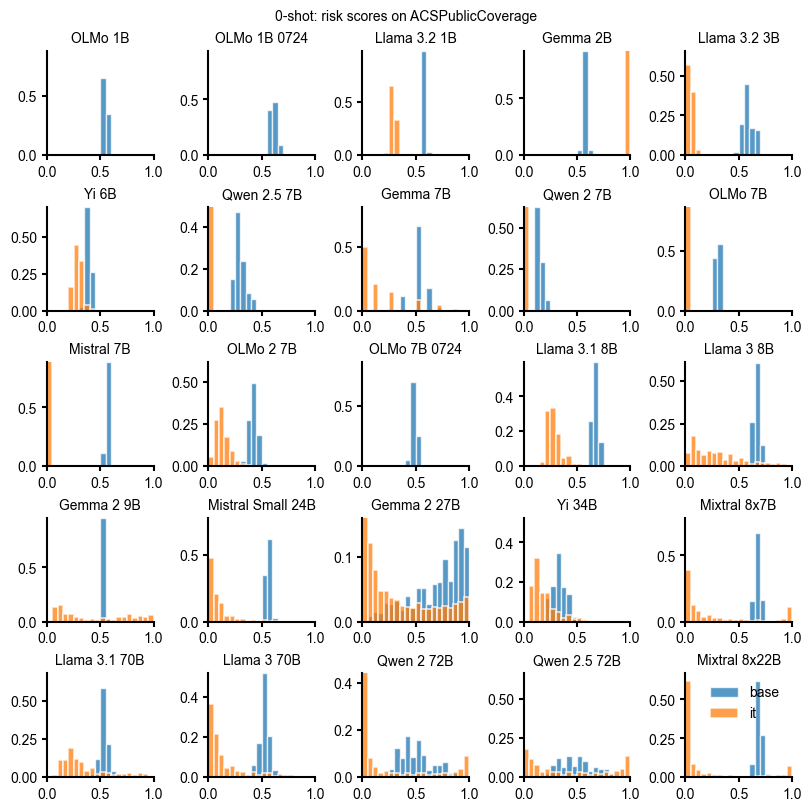

BRFSS_Diabetes


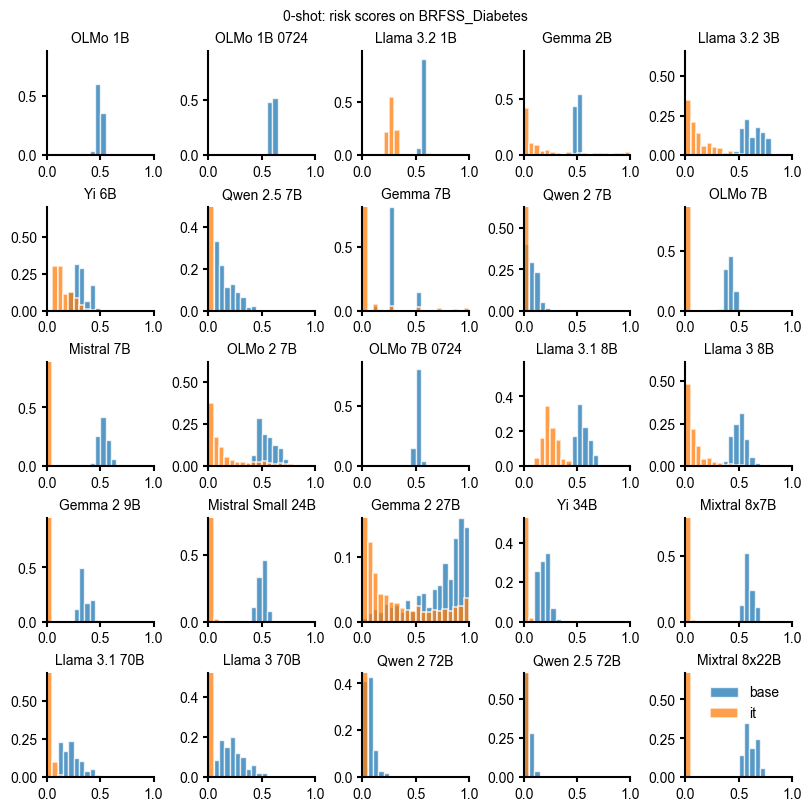

BRFSS_Blood_Pressure


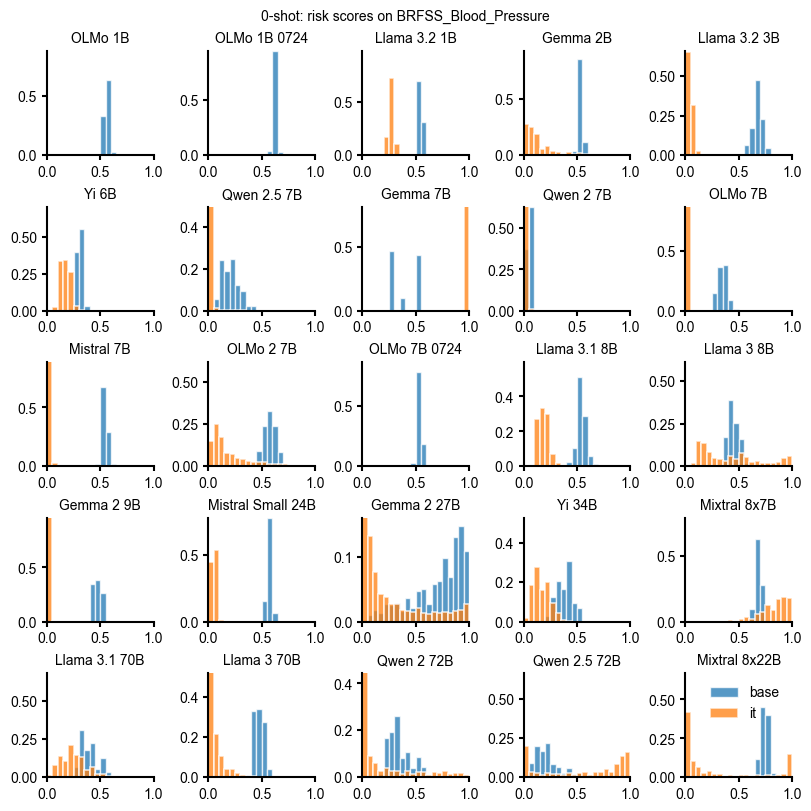

In [14]:
base_models = sorted(
    [model for model in models_common if not is_instruction_tuned(model)],
    key=get_size,
)
it_models = sorted(
    [model for model in models_common if is_instruction_tuned(model)],
    key=get_size,
)
len(base_models), len(it_models)


# to ensure axis are the same across plots, get max y value per model
ymax = {}
for model in base_models:
    ymax[model] = 0
    for task in TASKS:
        N = risk_scores[task].shape[0]
        task_max = max(
            np.histogram(
                risk_scores[task][model],
                weights=np.zeros((N,)) + 1.0 / N,
                bins=np.arange(0, 1.01, 0.05),
            )[0]
        )
        if task_max > ymax[model]:
            ymax[model] = task_max


for task in TASKS:
    print(task)
    N = risk_scores[task].shape[0]
    num_row, num_col = 5, 5
    fig, axs = plt.subplots(num_row, num_col, figsize=(8, 8), constrained_layout=True)
    fig.suptitle(f"{num_shots}-shot: risk scores on {task}")
    for i, model in enumerate(base_models):

        coresponding_it_model = [
            itm
            for itm in it_models
            if prettify_model_name(key_to_model(itm)).startswith(
                prettify_model_name(key_to_model(model))
            )
        ]
        # print(model, coresponding_it_model)

        axs[i // num_col, i % num_col].set_xlim(0.0, 1.0)
        axs[i // num_col, i % num_col].set_title(
            prettify_model_name(key_to_model(model))
        )
        ys, xs, _ = axs[i // num_col, i % num_col].hist(
            risk_scores[task][model],
            weights=np.zeros((N,)) + 1.0 / N,
            alpha=0.75,
            label="base",
            bins=np.arange(0, 1.01, 0.05),
            edgecolor="w",
            linewidth=1,
        )
        axs[i // num_col, i % num_col].set_ylim(0.0, ymax[model])
        if len(coresponding_it_model) == 1:
            axs[i // num_col, i % num_col].hist(
                risk_scores[task][coresponding_it_model[0]],
                weights=np.zeros((N,)) + 1.0 / N,
                alpha=0.75,
                label="it",
                bins=np.arange(0, 1.01, 0.05),
                edgecolor="w",
                linewidth=1.2,
            )
    axs[-1, -1].legend()

    plt.show()

## Fitted Threshold vs. not fitted

In [15]:
df_fitted = df[
    (df["num_shots"] == num_shots)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == 1)
]
df_not_fitted = df[
    (df["num_shots"] == num_shots)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == 0)
]

print(set(df_not_fitted['model'].unique()) == set(df_fitted['model'].unique()))

predictions_fitted = load_model_outputs_same_prompt(
    df_fitted, tasks=TASKS, return_risk_scores=False
)
predictions_not_fitted = load_model_outputs_same_prompt(
    df_not_fitted, tasks=TASKS, return_risk_scores=False
)

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for metric in metrics:
    df_fitted[metric] = (
        df_fitted["eval_results_path"]
        .apply(partial(get_metric, metric=metric))
        .copy()
    )
    df_not_fitted[metric] = (
        df_not_fitted["eval_results_path"]
        .apply(partial(get_metric, metric=metric))
        .copy()
    )

evals_per_task_fitted = {}  # [task][metric][model]
evals_per_task_not_fitted = {}  # [task][metric][model]
for task in df_fitted["task"].unique():
    df_task = df_fitted[df_fitted["task"] == task]
    evals_per_task_fitted[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }
for task in df_not_fitted["task"].unique():
    df_task = df_not_fitted[df_not_fitted["task"] == task]
    evals_per_task_not_fitted[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }

True


/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_49478/1533157445.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fitted[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_49478/1533157445.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_not_fitted[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_49478/1533157445.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

In [16]:
models_better_const_fitted = {
    task: [
        m
        for m in predictions_fitted[task].columns
        if df_fitted[
            (df_fitted["task"] == task) & (df_fitted["model"] == m)
        ]["accuracy"].item()
        > baseline_evals[task]["Constant"]["accuracy"]
    ]
    for task in TASKS
}

models_better_const_not_fitted = {
    task: [
        m
        for m in predictions_not_fitted[task].columns
        if df_not_fitted[
            (df_not_fitted["task"] == task) & (df_not_fitted["model"] == m)
        ]["accuracy"].item()
        > baseline_evals[task]["Constant"]["accuracy"]
    ]
    for task in TASKS
}

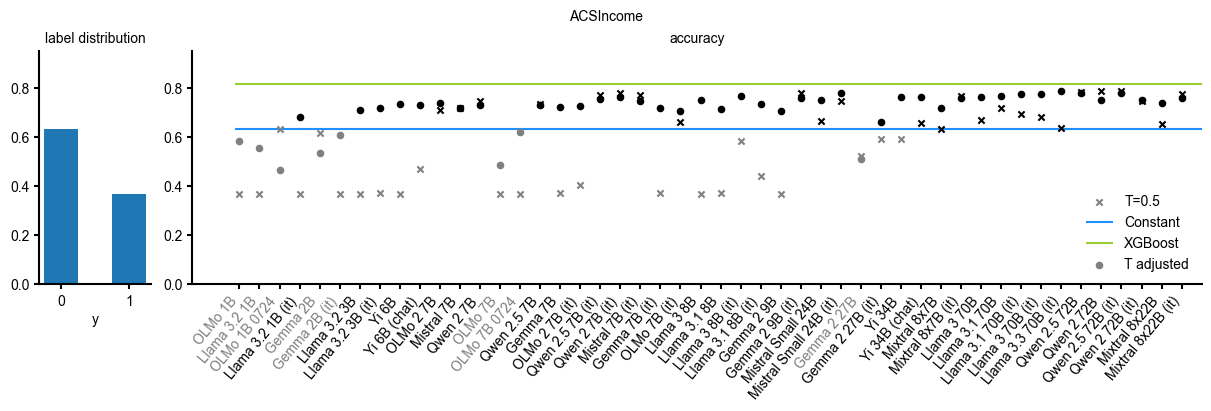

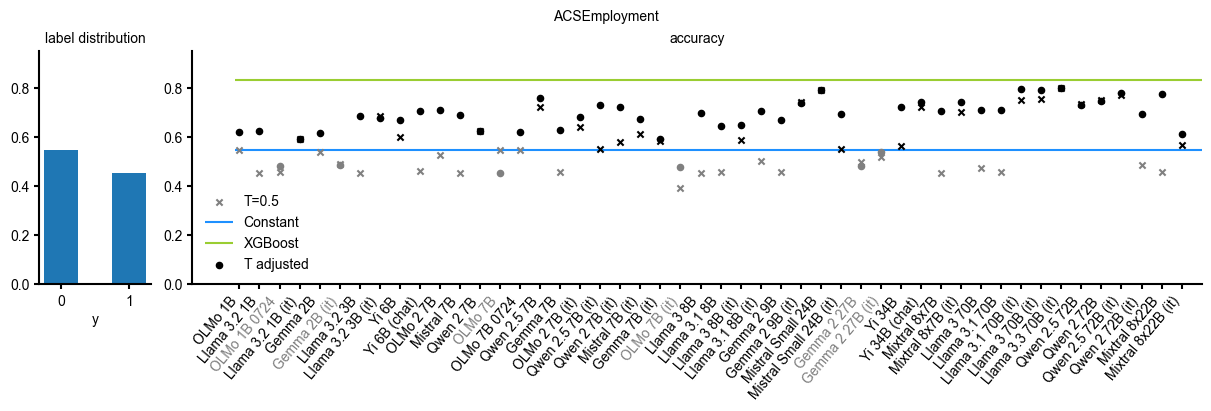

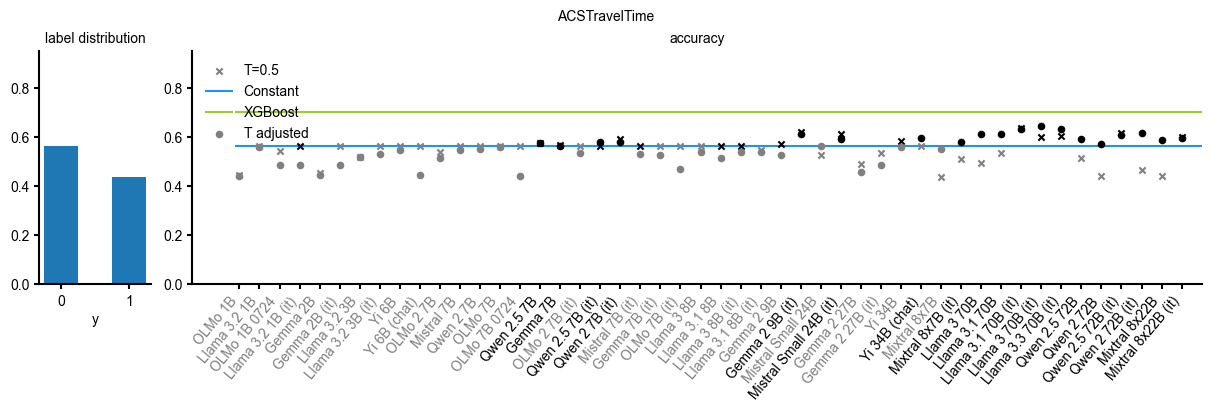

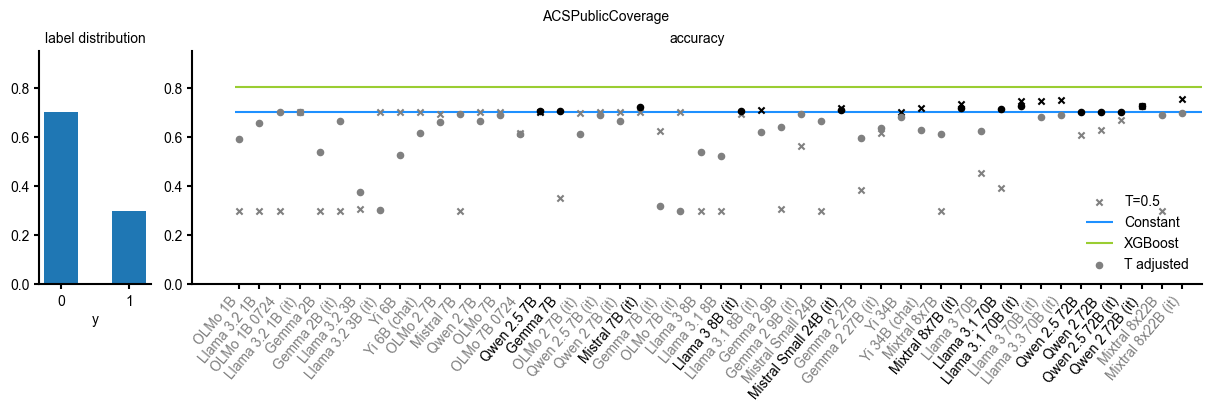

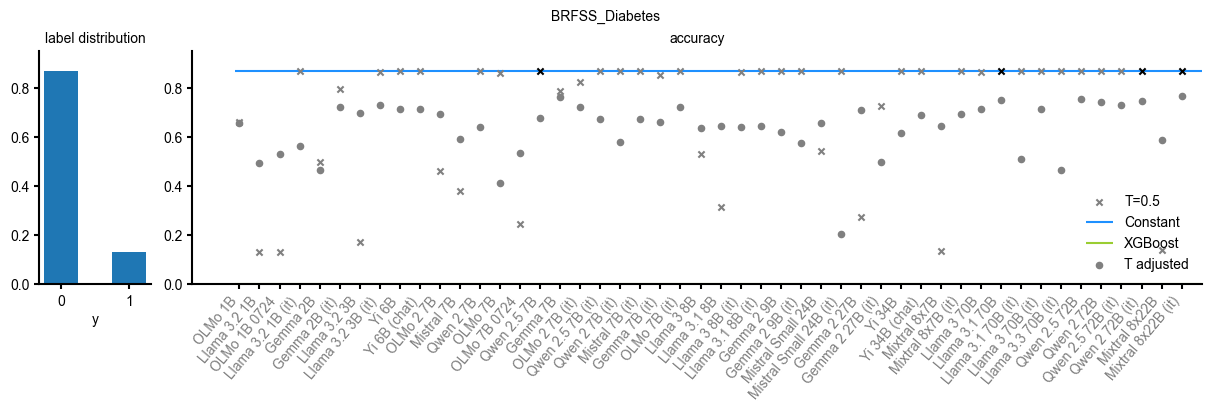

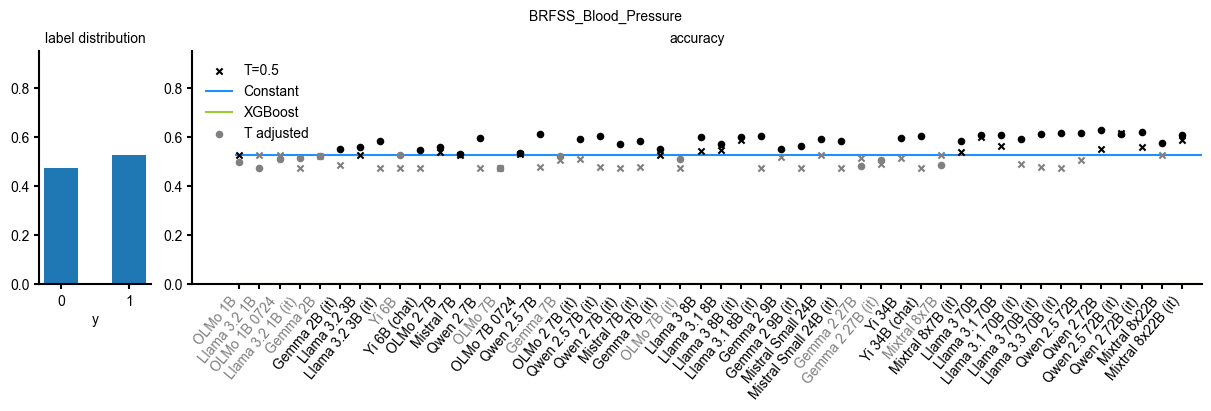

In [17]:
# one plot per task
for i, task in enumerate(
    TASKS
):  
    fig, axs = plt.subplots(
    1,
    2,
    figsize=(12, 4),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [1, 9]},
)
    
    fig.suptitle(task)
    axs[0].set_title("label distribution")
    axs[1].set_title("accuracy")
    pad = 5  

    ylims = (0, 0.95)
    
    # label distribution
    labels = data[task][1]
    axs[0] = plot_label_dist(axs[0], labels, ylims=ylims)

    # model accuracy
    # to exclude constant classifiers: evals = evals_non_const
    axs[1] = plot_accuracies(
        ax=axs[1],
        task=task,
        evals=evals_per_task_not_fitted,
        baseline_evals=None,
        models_above_baseline=models_better_const_not_fitted,
        ylims=ylims,
        marker="x",
        scatter_label='T=0.5'
    )
    axs[1] = plot_accuracies(
        ax=axs[1],
        task=task,
        evals=evals_per_task_fitted,
        baseline_evals=baseline_evals,
        models_above_baseline=models_better_const_fitted,
        hline_xmin=-0.2,
        hline_xmax=predictions_fitted[task].shape[1] + 0.1,
        ylims=ylims,
        marker="o",
        scatter_label='T adjusted',
    )

    #if task == "ACSIncome":
    # labels, handles = axs[1].get_legend_handles_labels()
    # sorted_handles_labels = sorted(zip(handles, labels), key=lambda item: item[0], reverse=True)
    # handles, labels = zip(*sorted_handles_labels)
    # axs[1].legend(handles, labels)

    axs[1].legend()
    # plt.savefig(RESULTS_ROOT_DIR/f'figures/same_prompt_model_performance_{task}.png')
    plt.show()

## 0-shot vs 10-shot

In [31]:
df_0shot[df_0shot['task'].apply(lambda t: t in set(df_10shot['task'].unique()).intersection(set(df_0shot['task'].unique())))]['task'].unique()

array(['ACSIncome', 'ACSEmployment', 'BRFSS_Diabetes',
       'BRFSS_Blood_Pressure'], dtype=object)

In [37]:
df_0shot = df[
    (df["num_shots"] == 0)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == threshold_fitted)
]
df_10shot = df[
    (df["num_shots"] == 10)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == threshold_fitted)
]

common_tasks = set(df_10shot['task'].unique()).intersection(set(df_0shot['task'].unique()))
df_0shot = df_0shot[df_0shot['task'].apply(lambda t: t in common_tasks)]
df_10shot = df_10shot[df_10shot['task'].apply(lambda t: t in common_tasks)]

print(set(df_10shot['model'].unique()) == set(df_0shot['model'].unique()))

predictions_0shot = load_model_outputs_same_prompt(
    df_0shot, tasks=common_tasks, return_risk_scores=False
)
predictions_10shot = load_model_outputs_same_prompt(
    df_10shot, tasks=common_tasks, return_risk_scores=False
)

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for metric in metrics:
    df_0shot[metric] = (
        df_0shot["eval_results_path"]
        .apply(partial(get_metric, metric=metric))
        .copy()
    )
    df_10shot[metric] = (
        df_10shot["eval_results_path"]
        .apply(partial(get_metric, metric=metric))
        .copy()
    )

evals_per_task_0shot = {}  # [task][metric][model]
evals_per_task_10shot = {}  # [task][metric][model]
for task in df_0shot["task"].unique():
    df_task = df_0shot[df_0shot["task"] == task]
    evals_per_task_0shot[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }
for task in df_10shot["task"].unique():
    df_task = df_10shot[df_10shot["task"] == task]
    evals_per_task_10shot[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }

True
ACSIncome 48
ACSEmployment 48
BRFSS_Diabetes 48
BRFSS_Blood_Pressure 48
ACSIncome 48
ACSEmployment 48
BRFSS_Diabetes 38
BRFSS_Blood_Pressure 38


In [39]:
models_better_const_0shot = {
    task: [
        m
        for m in predictions_0shot[task].columns
        if df_0shot[
            (df_0shot["task"] == task) & (df_0shot["model"] == m)
        ]["accuracy"].item()
        > baseline_evals[task]["Constant"]["accuracy"]
    ]
    for task in common_tasks
}

models_better_const_10shot = {
    task: [
        m
        for m in predictions_10shot[task].columns
        if df_10shot[
            (df_10shot["task"] == task) & (df_10shot["model"] == m)
        ]["accuracy"].item()
        > baseline_evals[task]["Constant"]["accuracy"]
    ]
    for task in common_tasks
}

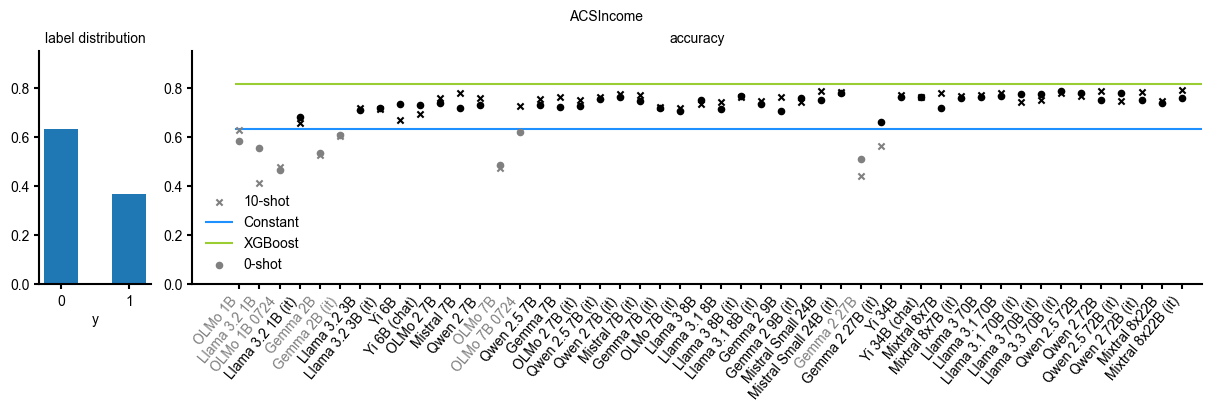

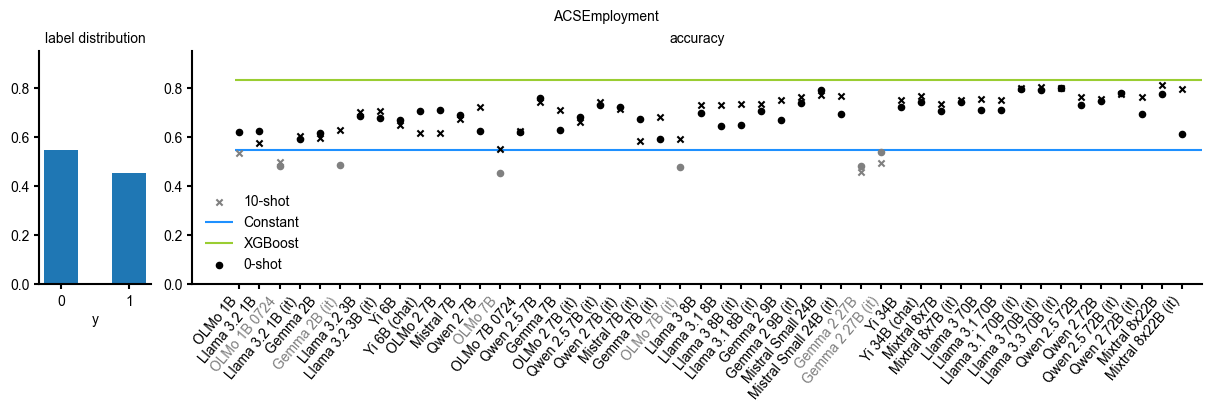

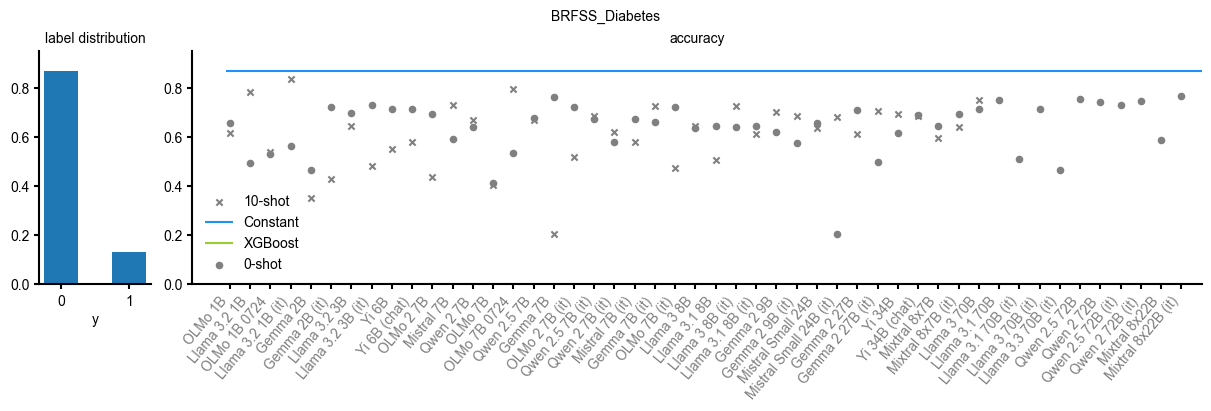

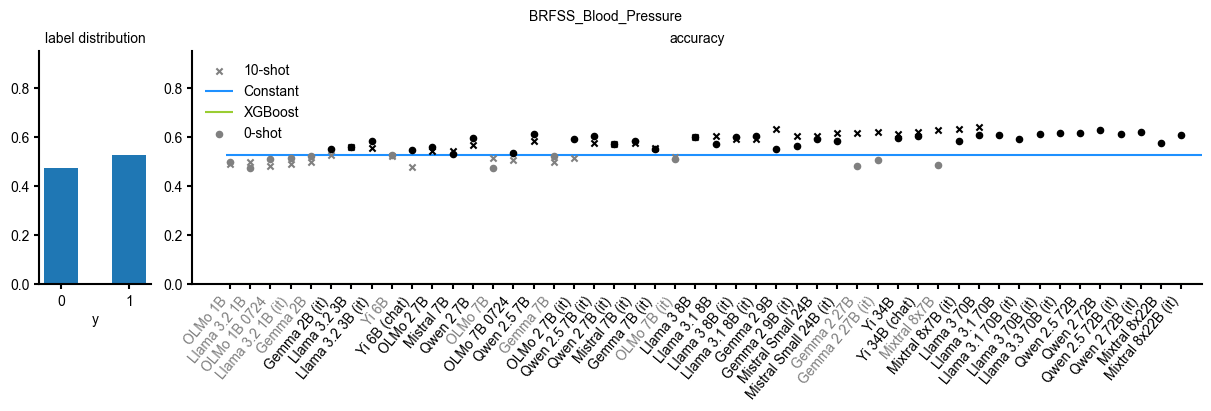

In [41]:
# one plot per task
for i, task in enumerate(
    common_tasks
):  
    fig, axs = plt.subplots(
    1,
    2,
    figsize=(12, 4),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [1, 9]},
)
    
    fig.suptitle(task)
    axs[0].set_title("label distribution")
    axs[1].set_title("accuracy")
    pad = 5  

    ylims = (0, 0.95)
    
    # label distribution
    labels = data[task][1]
    axs[0] = plot_label_dist(axs[0], labels, ylims=ylims)

    # model accuracy
    # to exclude constant classifiers: evals = evals_non_const
    axs[1] = plot_accuracies(
        ax=axs[1],
        task=task,
        evals=evals_per_task_10shot,
        baseline_evals=None,
        models_above_baseline=models_better_const_10shot,
        ylims=ylims,
        marker="x",
        scatter_label='10-shot'
    )
    axs[1] = plot_accuracies(
        ax=axs[1],
        task=task,
        evals=evals_per_task_0shot,
        baseline_evals=baseline_evals,
        models_above_baseline=models_better_const_0shot,
        hline_xmin=-0.2,
        hline_xmax=predictions_0shot[task].shape[1] + 0.1,
        ylims=ylims,
        marker="o",
        scatter_label='0-shot'
    )

    #if task == "ACSIncome":
    # labels, handles = axs[1].get_legend_handles_labels()
    # sorted_handles_labels = sorted(zip(handles, labels), key=lambda item: item[0], reverse=True)
    # handles, labels = zip(*sorted_handles_labels)
    # axs[1].legend(handles, labels)

    axs[1].legend()
    # plt.savefig(RESULTS_ROOT_DIR/f'figures/same_prompt_model_performance_{task}.png')
    plt.show()